In [1]:
import pandas as pd

df_forecast = pd.read_csv("healthcare_analytics_patient_flow_data.csv")

df_forecast.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [2]:

df_forecast["Patient Admission Date"] = pd.to_datetime(df_forecast["Patient Admission Date"])


admissions_only = df_forecast[df_forecast["Patient Admission Flag"] == "Admission"]


daily_admissions = admissions_only.groupby("Patient Admission Date").size().reset_index(name="Total_Admissions")

daily_admissions.head()

ValueError: time data "31/12/2023" doesn't match format "%m/%d/%Y", at position 114. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [3]:
df_forecast["Patient Admission Date"] = pd.to_datetime(
    df_forecast["Patient Admission Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df_forecast["Patient Admission Date"].isna().sum()

np.int64(0)

In [4]:

admissions_only = df_forecast[df_forecast["Patient Admission Flag"] == "Admission"].copy()


daily_admissions = (
    admissions_only
    .groupby("Patient Admission Date")
    .size()
    .reset_index(name="Total_Admissions")
    .sort_values("Patient Admission Date")
)

daily_admissions.head()

,Patient Admission Date,Total_Admissions
0,2023-04-01,9
1,2023-04-02,9
2,2023-04-03,7
3,2023-04-04,1
4,2023-04-05,10


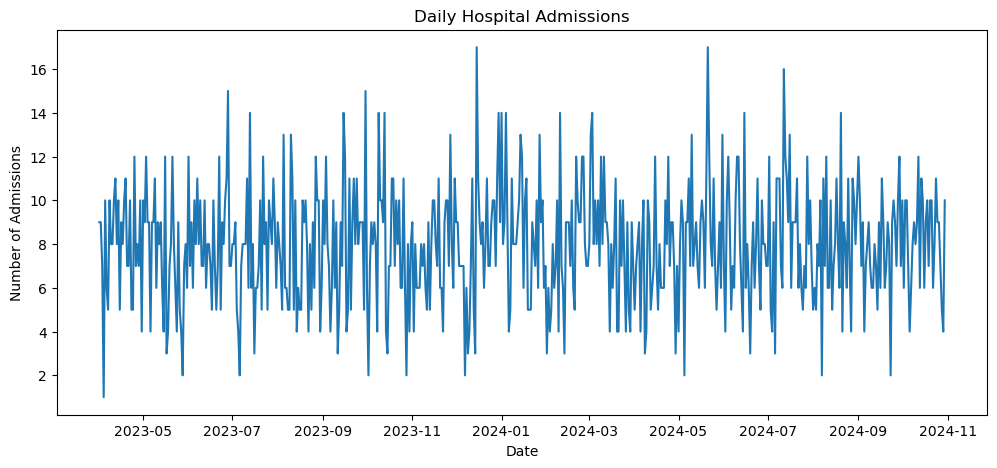

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_admissions["Patient Admission Date"],
         daily_admissions["Total_Admissions"])

plt.title("Daily Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")
plt.show()

In [6]:
prophet_df = daily_admissions.rename(
    columns={
        "Patient Admission Date": "ds",
        "Total_Admissions": "y"
    }
)

prophet_df.head()

,ds,y
0,2023-04-01,9
1,2023-04-02,9
2,2023-04-03,7
3,2023-04-04,1
4,2023-04-05,10


In [8]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 3.7 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 8.6 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.1 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 14.3 MB/s  0:00:01
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 6.7 MB/s  0:00:00

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   --------------

In [1]:
from prophet import Prophet

In [2]:
print("Prophet is working ")

Prophet is working 


In [5]:
import pandas as pd

df_forecast = pd.read_csv("healthcare_analytics_patient_flow_data.csv")
df_forecast.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [6]:
df_forecast["Patient Admission Date"] = pd.to_datetime(
    df_forecast["Patient Admission Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [7]:
admissions_only = df_forecast[df_forecast["Patient Admission Flag"] == "Admission"].copy()

In [8]:
daily_admissions = (
    admissions_only
    .groupby("Patient Admission Date")
    .size()
    .reset_index(name="Total_Admissions")
    .sort_values("Patient Admission Date")
)

daily_admissions.head()

,Patient Admission Date,Total_Admissions
0,2023-04-01,9
1,2023-04-02,9
2,2023-04-03,7
3,2023-04-04,1
4,2023-04-05,10


In [9]:
prophet_df = daily_admissions.rename(
    columns={
        "Patient Admission Date": "ds",
        "Total_Admissions": "y"
    }
)

prophet_df.head()

,ds,y
0,2023-04-01,9
1,2023-04-02,9
2,2023-04-03,7
3,2023-04-04,1
4,2023-04-05,10


In [10]:
from prophet import Prophet

model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

22:02:10 - cmdstanpy - INFO - Chain [1] start processing
22:02:14 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
599,2024-11-20,7.801539,4.576987,11.226451
600,2024-11-21,8.140008,4.442992,11.630413
601,2024-11-22,8.347040,4.878815,11.453190
602,2024-11-23,8.492558,5.335526,11.772821
603,2024-11-24,8.143579,4.764726,11.837545
604,2024-11-25,8.095428,4.625276,11.639287
605,2024-11-26,8.324038,5.037128,11.732462
606,2024-11-27,7.806596,4.380345,11.055897
607,2024-11-28,8.145065,4.991120,11.559062
608,2024-11-29,8.352097,4.846373,11.799984


NameError: name 'plt' is not defined

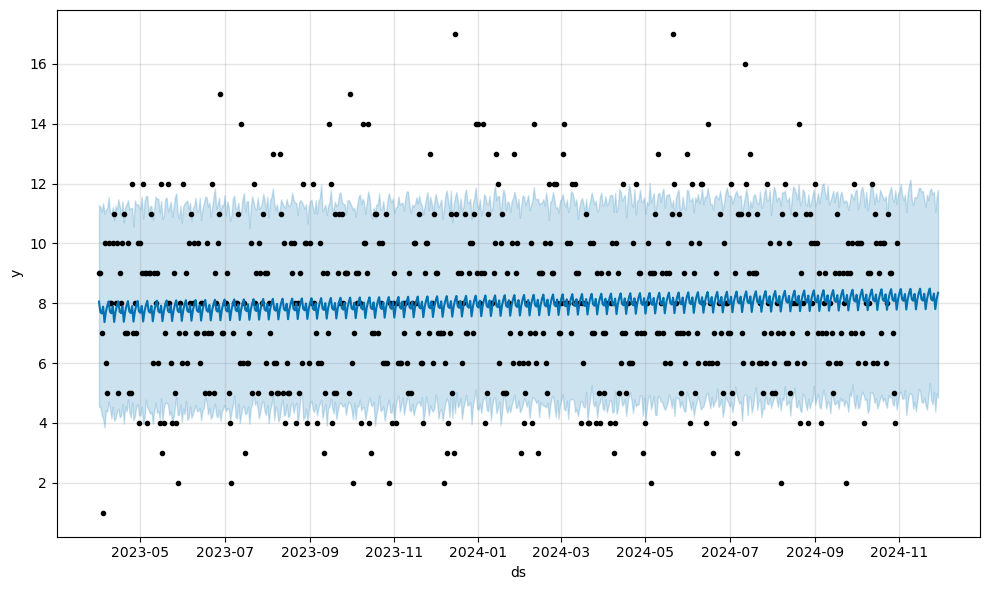

In [11]:
fig = model_prophet.plot(forecast)
plt.title("Hospital Admissions Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")
plt.show()

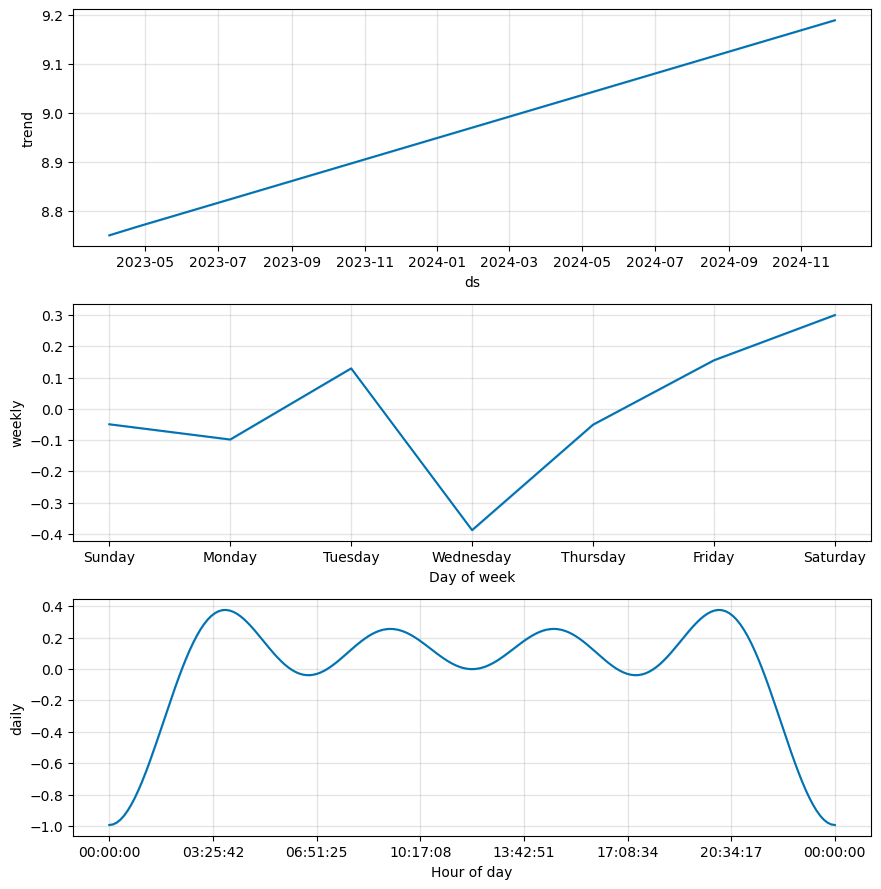

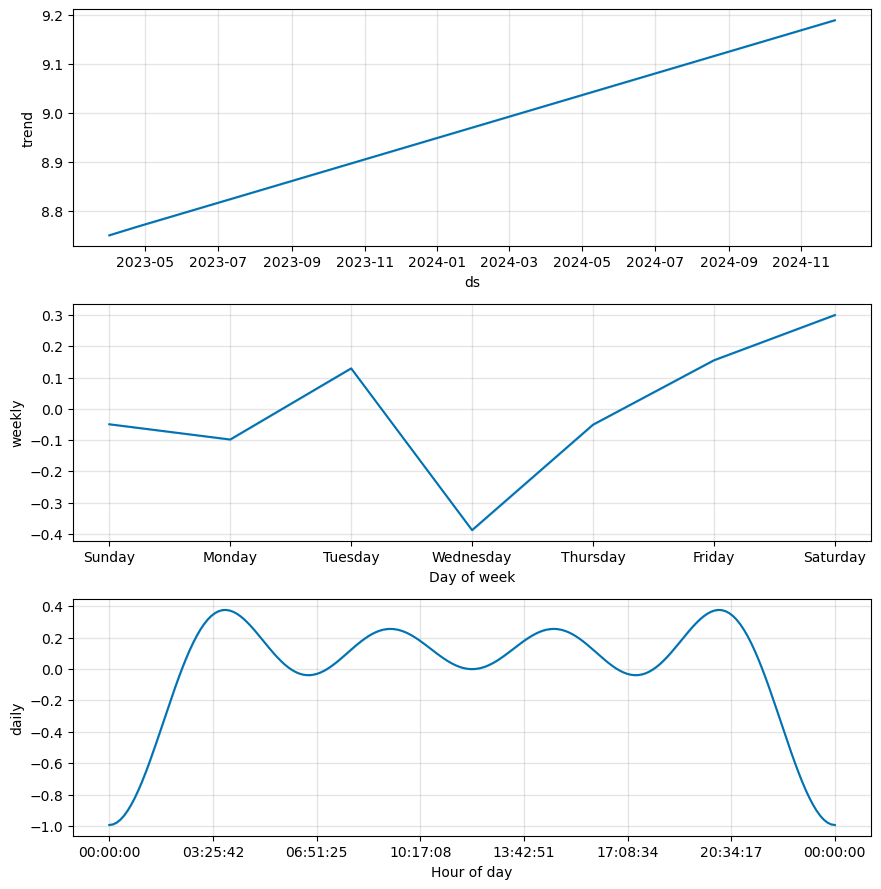

In [12]:
model_prophet.plot_components(forecast)

In [13]:

last_date = prophet_df["ds"].max()


next_30_days = forecast[forecast["ds"] > last_date]


next_30_days[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(30)

,ds,yhat,yhat_lower,yhat_upper
579,2024-10-31,8.124838,4.738187,11.660304
580,2024-11-01,8.331870,4.990100,11.748441
581,2024-11-02,8.477387,5.044908,11.980495
582,2024-11-03,8.128409,4.814321,11.619815
583,2024-11-04,8.080257,4.815301,11.437873
584,2024-11-05,8.308868,5.106685,11.632127
585,2024-11-06,7.791426,4.262950,11.044055
586,2024-11-07,8.129895,4.659609,11.690353
587,2024-11-08,8.336926,4.963001,11.952211
588,2024-11-09,8.482444,4.997621,12.141468


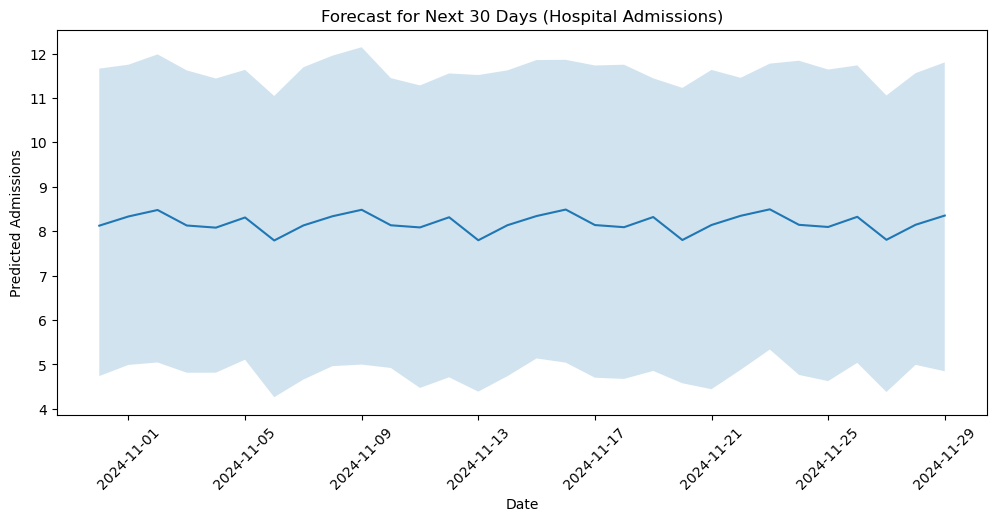

In [14]:
import matplotlib.pyplot as plt

# آخر تاريخ فعلي في البيانات
last_date = prophet_df["ds"].max()

# فلترة الـ 30 يوم القادمة
next_30 = forecast[forecast["ds"] > last_date].copy()

plt.figure(figsize=(12,5))
plt.plot(next_30["ds"], next_30["yhat"])
plt.fill_between(next_30["ds"], next_30["yhat_lower"], next_30["yhat_upper"], alpha=0.2)

plt.title("Forecast for Next 30 Days (Hospital Admissions)")
plt.xlabel("Date")
plt.ylabel("Predicted Admissions")
plt.xticks(rotation=45)
plt.show()

In [15]:
import os
os.getcwd()

'C:\\Users\\Alzam\\Healthcare_Project'

In [16]:
import pandas as pd

df_test = pd.read_csv("healthcare_analytics_patient_flow_data.csv")
df_test.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36
